In [1]:
import zipfile
import os

zip_path = "WikiTableQuestions-1.0.2-compact.zip"

extract_to = "WikiTableQuestions-1.0.2-compact"

os.makedirs(extract_to, exist_ok=True)

# Extract
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_to)

print("Unzipped successfully!")


Unzipped successfully!


# Imports

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import csv
from transformers import AutoModelForQuestionAnswering, AutoTokenizer, pipeline,AutoTokenizer, AutoModelForCausalLM
from evaluate import load
from huggingface_hub import login


2025-11-06 14:10:44.852522: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-11-06 14:10:45.403423: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-11-06 14:10:47.082102: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [3]:
train_data= pd.read_csv("WikiTableQuestions-1.0.2-compact/WikiTableQuestions/tagged/data/EN_training_cleaned.tagged")

In [4]:
test_data = pd.read_csv("WikiTableQuestions-1.0.2-compact/WikiTableQuestions/tagged/data/EN_pristine-unseen-tables_cleaned.tagged")

In [44]:
train_data.head()

,id,utterance,context,targetValue,tokens,lemmaTokens,posTags,nerTags,nerValues,targetCanon,targetCanonType,utterance_lng,topic,columnInQuestion,valueInQuestion,question_type,answerInTable
0,nt-0,what was the last year where this team was a p...,csv/204-csv/590.csv,2004,what|was|the|last|year|where|this|team|was|a|p...,what|be|the|last|year|where|this|team|be|a|par...,WP|VBD-AUX|DT|JJ|NN|WRB|DT|NN|VBD-AUX|DT|NN|IN...,O|O|DATE|DATE|DATE|O|O|O|O|O|O|O|O|MISC|O|O|O,||PREV_IMMEDIATE P1Y|PREV_IMMEDIATE P1Y|PREV_I...,2004.0,number,en,1,True,True,Other question,True
1,nt-1,in what city did piotr's last 1st place finish...,csv/204-csv/622.csv,"Bangkok, Thailand",in|what|city|did|piotr|'s|last|1st|place|finis...,in|what|city|do|piotr|'s|last|1st|place|finish...,IN|WDT|NN|VBD-AUX|NNP|POS|JJ|JJ|NN|NN|VB|.,O|O|O|O|PERSON|O|O|ORDINAL|O|O|O|O,|||||||1.0||||,"Bangkok, Thailand",string,en,3,False,True,Other question,True
2,nt-2,which team won previous to crettyard?,csv/204-csv/772.csv,Wolfe Tones,which|team|won|previous|to|crettyard|?,which|team|win|previous|to|crettyard|?,WDT|NN|VBD|JJ|TO|VB|.,O|O|O|O|O|O|O,||||||,Wolfe Tones,string,en,3,True,True,Other question,True
3,nt-3,how many more passengers flew to los angeles t...,csv/203-csv/515.csv,"12,467",how|many|more|passengers|flew|to|los|angeles|t...,how|many|more|passenger|fly|to|los|angeles|tha...,WRB|JJ|JJR|NNS|VBD|TO|NNP|NNP|IN|TO|NNP|IN|NNP...,O|O|O|O|O|O|LOCATION|LOCATION|O|O|LOCATION|O|L...,|||||||||||||||2013|,12467.0,number,en,2,True,True,Numerical question,False
4,nt-4,who was the opponent in the first game of the ...,csv/204-csv/495.csv,Derby County,who|was|the|opponent|in|the|first|game|of|the|...,who|be|the|opponent|in|the|first|game|of|the|s...,WP|VBD-AUX|DT|NN|IN|DT|JJ|NN|IN|DT|NN|.,O|O|O|O|O|O|ORDINAL|O|O|O|O|O,||||||1.0|||||,Derby County,string,en,2,True,False,Other question,True


In [48]:
print(f"train {len(train_data)}, test {len(test_data)}")


train 14035, test 4311


In [49]:
test_data.head()

,id,utterance,context,targetValue,tokens,lemmaTokens,posTags,nerTags,nerValues,targetCanon,targetCanonType,utterance_lng,topic,columnInQuestion,valueInQuestion,answerInTable,question_type
0,nu-0,which country had the most cyclists finish wit...,csv/203-csv/733.csv,Italy,which|country|had|the|most|cyclists|finish|wit...,which|country|have|the|most|cyclist|finish|wit...,WDT|NN|VBD-AUX|DT|JJS|NNS|VBP|IN|DT|JJ|CD|.,O|O|O|O|O|O|O|O|O|O|NUMBER|O,||||||||||10.0|,Italy,string,en,3,False,True,False,Numerical question
1,nu-1,how many people were murdered in 1940/41?,csv/204-csv/149.csv,"100,000",how|many|people|were|murdered|in|1940\\/41|?,how|many|people|be|murder|in|1940\\/41|?,WRB|JJ|NNS|VBD-AUX|VBN|IN|CD|.,O|O|O|O|O|O|NUMBER|O,|||||||,100000.0,number,en,3,False,True,True,Numerical question
2,nu-2,how long did it take for the new york american...,csv/203-csv/435.csv,17 years,how|long|did|it|take|for|the|new|york|american...,how|long|do|it|take|for|the|new|york|americans...,WRB|RB|VBD-AUX|PRP|VB|IN|DT|NNP|NNP|NNPS|TO|VB...,O|O|O|O|O|O|O|LOCATION|LOCATION|MISC|O|O|O|MIS...,||||||||||||||||1936|,17.0,number,en,1,True,True,False,Numerical question
3,nu-3,alfie's birthday party aired on january 19. wh...,csv/204-csv/803.csv,"January 26, 1995",alfie|'s|birthday|party|aired|on|january|19|.|...,alfie|'s|birthday|party|air|on|January|19|.|wh...,NNP|POS|NN|NN|VBD|IN|NNP|CD|.|WP|VBD-AUX|DT|NN...,PERSON|O|O|O|O|O|DATE|DATE|O|O|O|O|O|O|O|O|O|O,||||||XXXX-01-19|XXXX-01-19||||||||||,1995-01-26,date,en,3,False,True,True,Temporal question
4,nu-4,what is the number of 1st place finishes acros...,csv/204-csv/272.csv,17,what|is|the|number|of|1st|place|finishes|acros...,what|be|the|number|of|1st|place|finish|across|...,WP|VBD-AUX|DT|NN|IN|CD|NN|NNS|IN|DT|NNS|.,O|O|O|O|O|ORDINAL|O|O|O|O|O|O,|||||1.0||||||,17.0,number,en,3,False,False,False,Numerical question


# Protocole D'experimentation

# Convert tables to RAW text (lin_rep)

Here, we will first pass the tables directly as string  representation,  and apply text Q&A and seee the results. We cann this lin_rep.

## Creation d'un fichier contenant les infos des tables

In [51]:
#recuperer les tables et ne creer un fichier table pour que ca soit plus simple
'''
data: les donnees qu'on passe
suffixe : "train" ou "test"
'''
def create_table_file(data,suffixe):
    assert all(col in data.columns for col in ["context", "utterance"]), "wrong data file passed, doesn't contain context or utterance"
    assert suffixe in ["train", "test"], "suffixe is not train or test"
    
    unique_context=np.unique(data["context"])
    print(f"Number of tables in {suffixe} is {len(unique_context)}")
    
    table_linearization=[]
    table_columns=[]
    for context in unique_context:
        with open(f"WikiTableQuestions-1.0.2-compact/WikiTableQuestions/{context[:-4]}.table", "r") as f:
            lines = f.readlines()
            headers= lines[0]
            table= "".join(lines)
            
        table_linearization.append(table)  
        columns=headers.split('|')[1:-1]
        table_columns.append([c.strip() for c in columns]) #take columns and disregard the first one caus its empty
        

    print(f"Number of tables written to table file of {suffixe} is {len(table_columns)}") 
    
    table_df = pd.DataFrame({
        "context": unique_context,
        "lin_rep": table_linearization,
        "columns": table_columns})
    
    #save df of tables as a file
    table_df.to_csv(f"./WikiTableQuestions-1.0.2-compact/WikiTableQuestions/tables_metadata_{suffixe}.csv", index=False) 
    print(f"Table data for {suffixe} saved to './WikiTableQuestions-1.0.2-compact/WikiTableQuestions/tables_metadata_{suffixe}.csv'")
    return table_df

In [47]:
tbtr= create_table_file(train_data,"train")

Number of tables in train is 1676
Number of tables written to table file of train is 1676
Table data for train saved to './WikiTableQuestions-1.0.2-compact/WikiTableQuestions/tables_metadata_train.csv'


In [52]:
tbts= create_table_file(test_data,"test")

Number of tables in test is 421
Number of tables written to table file of test is 421
Table data for test saved to './WikiTableQuestions-1.0.2-compact/WikiTableQuestions/tables_metadata_test.csv'


In [22]:
table_df_train= pd.read_csv("./WikiTableQuestions-1.0.2-compact/WikiTableQuestions/tables_metadata_train.csv") 
table_df_test= pd.read_csv("./WikiTableQuestions-1.0.2-compact/WikiTableQuestions/tables_metadata_test.csv") 

In [54]:
print("train",len(table_df_train), "test", len(table_df_test)) #contient toutes le stables anyway

train 1676 test 421


In [51]:
table_df_train.head()


,context,lin_rep,columns
0,csv/200-csv/0.csv,| Year | Title | Char...,"['Year', 'Title', 'Chart-Positions UK', 'Chart..."
1,csv/200-csv/1.csv,| Year | Title ...,"['Year', 'Title', 'Role', 'Notes']"
2,csv/200-csv/10.csv,| year | deaths | # of accidents |\n| 2012 | 7...,"['year', 'deaths', '# of accidents']"
3,csv/200-csv/12.csv,| Year | Award | Category ...,"['Year', 'Award', 'Category', 'Nominated work'..."
4,csv/200-csv/14.csv,| Act | Year signed | # Albums...,"['Act', 'Year signed', '# Albums released unde..."


In [55]:
table_df_test.head()

,context,lin_rep,columns
0,csv/200-csv/11.csv,| Award | Cat...,"['Award', 'Category', 'Nominee', 'Result']"
1,csv/200-csv/18.csv,| Frequency | Call sign | Name ...,"['Frequency', 'Call sign', 'Name', 'Format', '..."
2,csv/200-csv/24.csv,| Film | Film...,"['Film', 'Film', 'Date']"
3,csv/200-csv/29.csv,| Club performance Season Norway | Club perfor...,"['Club performance Season Norway', 'Club perfo..."
4,csv/200-csv/34.csv,| Character | Actor |...,"['Character', 'Actor', 'Series', 'Notes']"


## Representations en paragraphe

In [10]:
#dictionaire pour mapper plus facilement la representation a la colomne qui va avec
# 0: linéarisation simple, 1: Paragraphe généré par LLM sans Format, 2: Pargraphe genere par LLM avec format
map_rep={
    0: "lin_rep",
    1: "llm_gen",
    2: "llm_format"
}

In [12]:
""" Retourne une représentation du contexte
context= la reference de la table, ex: 'csv/200-csv/14.csv'
rep= 0: linéarisation simple, 1: Paragraphe généré par LLM sans Format, 2:Paragraphe généré par LLM avec Format
contexts_table: la dataframe qui contient les info des tables (table_df)
"""
def get_rep_from_table(context, rep, contexts_table):  
    res= contexts_table[contexts_table["context"]==context][map_rep[rep]].values[0] #gets the right representation for the given table "context"
    return res

In [55]:
get_rep_from_table("csv/200-csv/14.csv",0, table_df_train) #test

'| Act                 | Year signed | # Albums released under Bad Boy |\n| Diddy               | 1993        | 6                               |\n| The Notorious B.I.G | 1993        | 5                               |\n| Harve Pierre        | 1993        | –                               |\n| The Hitmen          | 1993        | –                               |\n| Mario Winans        | 1995        | 1                               |\n| Kalenna Harper      | 2004        | –                               |\n| Cassie              | 2006        | 1                               |\n| Janelle Monáe       | 2007        | 2                               |\n| Red Café            | 2009        | –                               |\n| Machine Gun Kelly   | 2011        | 1                               |\n| French Montana      | 2012        | 1                               |\n| Megan Nicole        | 2012        | –                               |\n'

In [58]:
get_rep_from_table("csv/200-csv/18.csv",0, table_df_test) #test

'| Frequency | Call sign | Name                             | Format          | Owner                                                    | Target city/market | City of license |\n| 89.7 FM   | KUSD      | South Dakota Public Broadcasting | NPR             | SD Board of Directors for Educational Telecommunications | Yankton/Vermillion | Vermillion      |\n| 93.1 FM   | KKYA      | KK93                             | Country         | Riverfront Broadcasting LLC                              | Yankton/Vermillion | Yankton         |\n| 94.3 FM   | KDAM      | The Dam                          | Mainstream Rock | Riverfront Broadcasting LLC                              | Yankton/Vermillion | Hartington      |\n| 104.1 FM  | WNAX-FM   | The Wolf 104.1                   | Country         | Saga Communications                                      | Yankton/Vermillion | Yankton         |\n| 106.3 FM  | KVHT      | Classic Hits 106.3               | Classic Hits    | Cullhane Communications, Inc. 

## evaluation of lin_rep

In [13]:
def em_score(p,r): #calcul du score EM pour une prediciton p et une reference r
    if not isinstance(r, str): return 0 
    return 1 if p.lower().strip()==r.lower().strip() else  0

In [14]:
model_name= "deepset/roberta-base-squad2"
qa_model = pipeline("question-answering", model=model_name, tokenizer=model_name)


Device set to use cuda:0


In [61]:
#test
result = qa_model(question="In what year was hIBA born?",  context="Hiba was born on septmber 19th, 2002")
print(result)

{'score': 0.976372480392456, 'start': 32, 'end': 36, 'answer': '2002'}


In [15]:
'''
Fonction pour run le modele Q&A.
model: modle de Q&A
rep: representation 0, 1, 2 ou 3
data= df qui contient les donnees 
suffixe: "train" or "test"
'''

# ! YA BCP DE REPITIITON DE READ ET WRITE DANS LE FICHIER PCQ CA CRASHAIT ET JE POUVAIS PAS REFAIRE LES CALCULS CHAQUE FOIS DONC C'EST NORMAL

def run_QA(rep, qa_model, data, suffixe):

    #verifciation qu'on passe des donnees correctes
    assert all(col in data.columns for col in ["context", "utterance"]), "wrong data file passed, doesnt contain context or utterance"
    assert suffixe in ["train", "test"], "suffixe is not train or test"

    table_df= pd.read_csv(f"./WikiTableQuestions-1.0.2-compact/WikiTableQuestions/tables_metadata_{suffixe}.csv") 
  
        
    contexts=[get_rep_from_table(c, rep, table_df) for c in data["context"]] #recuperer les representations
    results= qa_model(question= data["utterance"].tolist(), context=contexts)

    #creer nouvelle df pour store les resultats
    results_df = data[["id","utterance","context","targetValue"]]
    
    results_df[f"pred_{rep}"]= [r["answer"] for r in results]
    results_df.to_csv(f"./WikiTableQuestions-1.0.2-compact/WikiTableQuestions/qa_res_{suffixe}_{rep}.csv",index=False)
    results_df= pd.read_csv(f"./WikiTableQuestions-1.0.2-compact/WikiTableQuestions/qa_res_{suffixe}_{rep}.csv")
    failed= results_df[f'pred_{rep}'].isna() | (results_df[f'pred_{rep}'] == "")
    
    print(f"The Q&A model failed to generate an answer for: {failed.sum()} instances. Thye were replaced by 'QA Generation Error'")

    results_df.loc[failed, f'pred_{rep}'] = 'QA Generation Error'
    results_df.to_csv(f"./WikiTableQuestions-1.0.2-compact/WikiTableQuestions/qa_res_{suffixe}_{rep}.csv",index=False)
    
    print(f"Results of Q&A saved to ./WikiTableQuestions-1.0.2-compact/WikiTableQuestions/qa_res_{suffixe}_{rep}.csv")
    return results
    

In [17]:
#Fonction pour evaluer les resultats, par contre on pourra pas faire de test statistiques pcq ca retourne un resultat aggrege
"""
rep is la representation 0, 1, 2 or 3
suffixe is "train " or "test"
"""
def evaluate_rep(rep, suffixe):

    res_data= pd.read_csv(f"./WikiTableQuestions-1.0.2-compact/WikiTableQuestions/qa_res_{suffixe}_{rep}.csv")
    if suffixe=="train":
        data= pd.read_csv("WikiTableQuestions-1.0.2-compact/WikiTableQuestions/tagged/data/EN_training_cleaned.tagged")
    else:
        data= pd.read_cvs("WikiTableQuestions-1.0.2-compact/WikiTableQuestions/tagged/data/EN_pristine-unseen-tables_cleaned.tagged")
    
    
    data_and_res= pd.merge(res_data, data[["id","targetValue"]], on="id", how="inner") #merge both files to access predictions and targetValue

    pred_formatted = [{"id": str(i), "prediction_text": p} for i, p in enumerate(data_and_res[f'pred_{rep}'].tolist())]
    target_formatted  = [{"id": str(i), "answers": {"text": [t], "answer_start": [0]}}  # answer_start ignored
             for i, t in enumerate(data_and_res['targetValue'].tolist())]
    
    em_binary = [em_score(p["prediction_text"], r["answers"]["text"][0]) for p, r in zip(pred_formatted, target_formatted)]
    data_and_res[f"EM_score_pred_{rep}"]= em_binary
    data_and_res.drop(columns=["targetValue"], inplace=True)
    data_and_res.to_csv(f"./WikiTableQuestions-1.0.2-compact/WikiTableQuestions/qa_res_{suffixe}_{rep}.csv",index=False)
    
    metric = load("squad")
    results = metric.compute(predictions= pred_formatted, references= target_formatted )
    return results


In [ ]:
# res= run_QA(0, qa_model, train_data, "train") #DONT RUN do it from fichier python "run_QA.py"

In [63]:
results= evaluate_rep(0, "train") #run pour une eval rapide et aggregee
results

Using the latest cached version of the SQuAD evaluation module from the local Hugging Face cache.


{'exact_match': 10.260064125400783, 'f1': 12.596082259051679}

In [64]:
#example
print("Question: ------------ ", train_data["utterance"][0])
print("Table RAW---------------------\n",get_rep_from_table(train_data["context"][0],0, table_df_train))
print("Table Rep---------------------\n",get_rep_from_table(train_data["context"][0],0, table_df_train))
print("MODEL ANSWER--------------------\n",qa_model(question= train_data["utterance"][0], context=get_rep_from_table(train_data["context"][0],0, table_df_train)))
print("Target Answer:-------------------- ", train_data["targetValue"][0])

Question: ------------  what was the last year where this team was a part of the usl a-league?
Table RAW---------------------
 | Year | Division | League              | Regular Season | Playoffs        | Open Cup        | Avg. Attendance |
| 2001 | 2        | USL A-League        | 4th, Western   | Quarterfinals   | Did not qualify | 7,169           |
| 2002 | 2        | USL A-League        | 2nd, Pacific   | 1st Round       | Did not qualify | 6,260           |
| 2003 | 2        | USL A-League        | 3rd, Pacific   | Did not qualify | Did not qualify | 5,871           |
| 2004 | 2        | USL A-League        | 1st, Western   | Quarterfinals   | 4th Round       | 5,628           |
| 2005 | 2        | USL First Division  | 5th            | Quarterfinals   | 4th Round       | 6,028           |
| 2006 | 2        | USL First Division  | 11th           | Did not qualify | 3rd Round       | 5,575           |
| 2007 | 2        | USL First Division  | 2nd            | Semifinals      | 2nd R

## analysis of lin_rep results

In [1]:
# TO DO analyse des resultats

In [18]:
res_0_train_df= pd.read_csv("./WikiTableQuestions-1.0.2-compact/WikiTableQuestions/qa_res_train_0.csv")
res_0_train_df.head()

,id,utterance,context,targetValue,pred_0,EM_score_pred_0
0,nt-0,what was the last year where this team was a p...,csv/204-csv/590.csv,2004,2001,0
1,nt-1,in what city did piotr's last 1st place finish...,csv/204-csv/622.csv,"Bangkok, Thailand",Bangkok,0
2,nt-2,which team won previous to crettyard?,csv/204-csv/772.csv,Wolfe Tones,Greystones,0
3,nt-3,how many more passengers flew to los angeles t...,csv/203-csv/515.csv,"12,467","14,749",0
4,nt-4,who was the opponent in the first game of the ...,csv/204-csv/495.csv,Derby County,Oldfield,0


In [6]:
import matplotlib.pyplot as plt

def plot_predict_by_answertype2(df, column_pred, title):
    
    fig, ax = plt.subplots(figsize=(5,5))
    correct_pred = df[df[column_pred] == 1]
    counts = correct_pred['targetCanonType'].value_counts(normalize=True) * 100
    
    counts.plot(kind='bar', ax=ax)
    ax.set_title(f'Percentage of Correct Predictions by Answer Type - {title}')
    ax.set_xlabel('Answer Type')
    ax.set_ylabel('% of Correct Predictions')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
    plt.tight_layout()

    for i, v in enumerate(counts):
        ax.text(i, v + 0.5, f"{v:.1f}%", ha='center', va='bottom', fontsize=9)

    plt.show()


def plot_predict_by_questionType(df, column_pred, title):
    fig, ax = plt.subplots(figsize=(5,5))
    counts = df.groupby(['question_type', column_pred]).size().unstack(fill_value=0)
    counts.plot(kind='bar', stacked=True, ax=ax)

    ax.set_title(f'Number of Correct vs Incorrect Answers per Question Type - {title}')
    ax.set_xlabel('Question Type')
    ax.set_ylabel('Number of Questions')
    ax.legend(title='EM Prediction Score', labels=['0', '1'])
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
    plt.tight_layout()
    plt.show()


def plot_predict_by_answertype(df, column_pred, title):
    fig, ax = plt.subplots(figsize=(5,5))
    counts = df.groupby(['targetCanonType', column_pred]).size().unstack(fill_value=0)
    counts.plot(kind='bar', stacked=True, ax=ax)

    ax.set_title(f'Number of Correct vs Incorrect Answers per Answer Type - {title}')
    ax.set_xlabel('Answer Type')
    ax.set_ylabel('Number of Questions')
    ax.legend(title='EM Prediction Score', labels=['0', '1'])
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
    plt.tight_layout()
    plt.show()


def plot_predict_by_answerinTable(df, column_pred, title):
    fig, ax = plt.subplots(figsize=(5,5))
    counts = df.groupby(['answerInTable', column_pred]).size().unstack(fill_value=0)
    counts.plot(kind='bar', stacked=True, ax=ax)

    ax.set_title(f'Number of Correct vs Incorrect Answers by presence in table - {title}')
    ax.set_xlabel('Answer In Table')
    ax.set_ylabel('Number of Questions')
    ax.legend(title='EM Prediction Score', labels=['0', '1'])
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
    plt.tight_layout()
    plt.show()

def plot_predict_by_columnInQuestion(df, column_pred, title):
    fig, ax = plt.subplots(figsize=(5,5))
    counts = df.groupby(['columnInQuestion', column_pred]).size().unstack(fill_value=0)
    counts.plot(kind='bar', stacked=True, ax=ax)

    ax.set_title(f'Number of Correct vs Incorrect Answers by presence of column name in question - {title}')
    ax.set_xlabel('Column In Question')
    ax.set_ylabel('Number of Questions')
    ax.legend(title='EM Prediction Score', labels=['0', '1'])
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
    plt.tight_layout()
    plt.show()

def plot_all(rep, suffixe ):
    res_data= pd.read_csv(f"./WikiTableQuestions-1.0.2-compact/WikiTableQuestions/qa_res_{suffixe}_{rep}.csv")
    if suffixe=="train":
        data= pd.read_csv("WikiTableQuestions-1.0.2-compact/WikiTableQuestions/tagged/data/EN_training_cleaned.tagged")
    else:
        data= pd.read_csv("WikiTableQuestions-1.0.2-compact/WikiTableQuestions/tagged/data/EN_pristine-unseen-tables_cleaned.tagged")

    data_and_res= pd.merge(data, res_data, on="id", how="inner") #merge both files to access predictions and data features

    
    plot_predict_by_answerinTable(data_and_res, f"EM_score_pred_{rep}", map_rep[rep])
    plot_predict_by_columnInQuestion(data_and_res, f"EM_score_pred_{rep}", map_rep[rep])
    plot_predict_by_answertype(data_and_res,  f"EM_score_pred_{rep}", map_rep[rep])
    plot_predict_by_questionType(data_and_res, f"EM_score_pred_{rep}", map_rep[rep])
    plot_predict_by_answertype2(data_and_res,  f"EM_score_pred_{rep}", map_rep[rep])


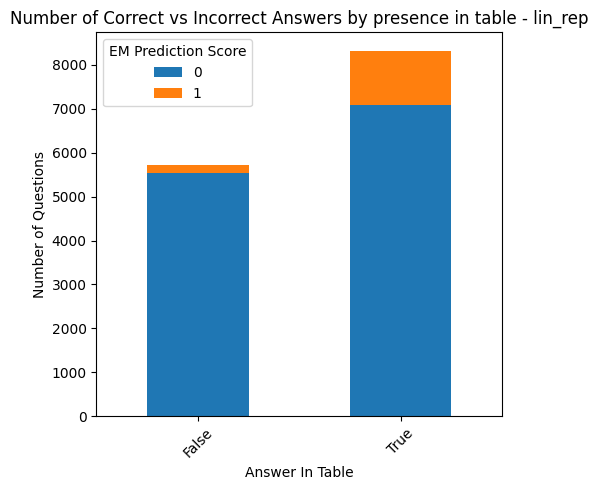

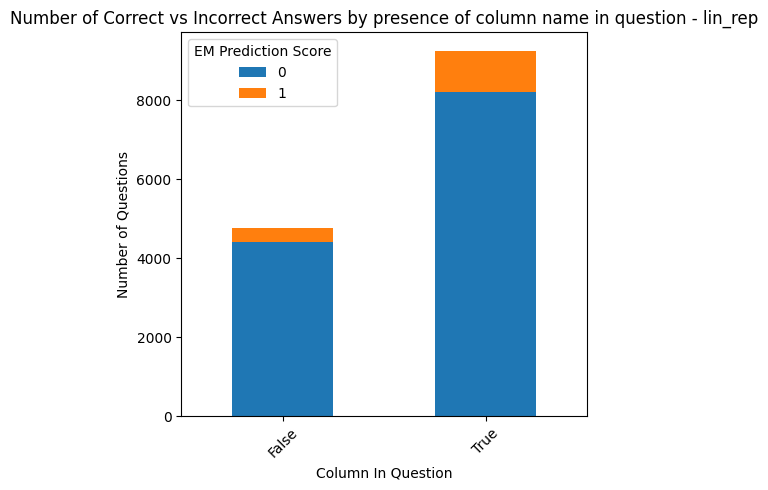

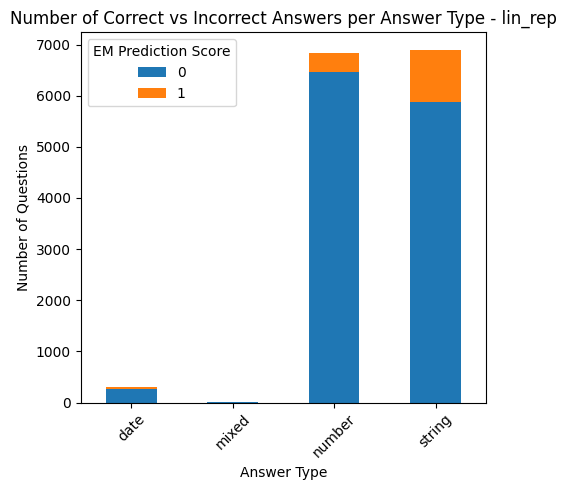

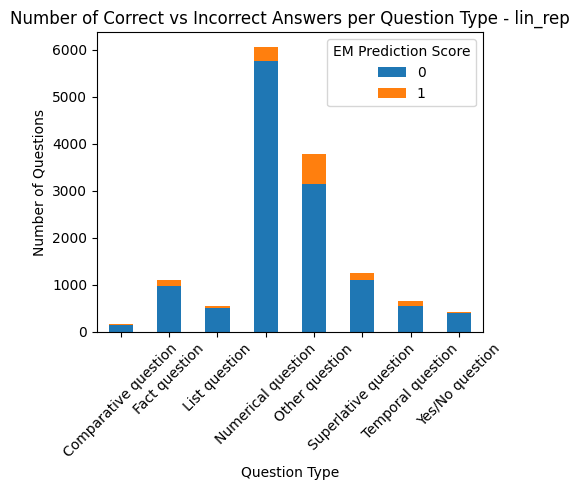

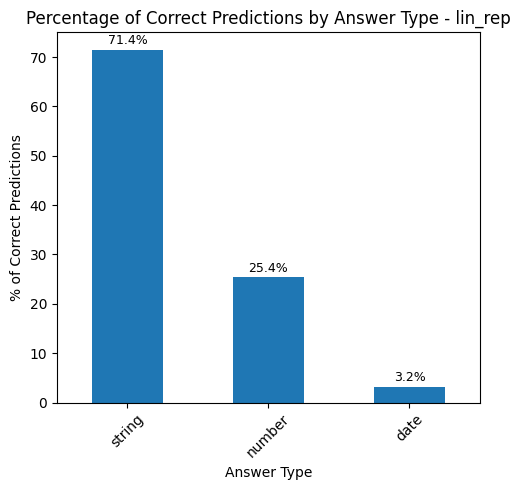

In [ ]:
plot_all(0, "train")

# LLM REP 1 (Simple LLM prompt)


In [24]:
from transformers import AutoTokenizer, AutoModelForCausalLM, pipeline


In [25]:
from huggingface_hub import login
# Authenticate with Hugging Face before running this notebook.

login()


In [ ]:
#RUN PAR FICHIER PYTHON

In [26]:
model_name= "meta-llama/Meta-Llama-3-8B-Instruct"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(model_name, device_map="auto")

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

In [27]:
generator = pipeline(
    "text-generation",
    model=model,
    tokenizer=tokenizer,
    max_new_tokens=600,
    temperature=0.7
)

Device set to use cuda:0


In [30]:
# prompt= "You are am expert data analyst. For a given table, generate a paragraph that summarizes all of the information found in the table. Each value in the table is separated by a delimiter '|'.  \n  Table: \n {table}\n Now summarize :\n  "
prompt= "You are an expert data analyst that converts tables into text. For a given table, generate a single paragraph summarizing the table row by row, using the values of each column. You must include all information and values present in the table in your paragrph. The first row represents column names. In your answer, include only the paragraph and nothing additional. Be neutral and precise. Example: \n Table:\n {table_example} \n Paragraph: {exp_example} \n Now, do the same for this table. \n Table:\n {table} \n Paragraph:  "
table_example="| Party      | Active Voters | Inactive Voters | Total Voters | Percentage |\n| Democratic | 3,683         | 251             | 3,934        | 36.93%     |\n"
exp_example="The Democratic Party has 3,683 active voters and 251 inactive voters, for a total of 3,934 voters, which represents 36.93% of all voters."
prompts= [prompt.format(table=t, table_example= table_example, exp_example=exp_example) for t in table_df["lin_rep"] ]

prompts[16]

'You are an expert data analyst that converts tables into text. For a given table, generate a single paragraph summarizing the table row by row, using the values of each column. You must include all information and values present in the table in your paragrph. The first row represents column names. In your answer, include only the paragraph and nothing additional. Be neutral and precise. Example: \n Table:\n | Party      | Active Voters | Inactive Voters | Total Voters | Percentage |\n| Democratic | 3,683         | 251             | 3,934        | 36.93%     |\n \n Paragraph: The Democratic Party has 3,683 active voters and 251 inactive voters, for a total of 3,934 voters, which represents 36.93% of all voters. \n Now, do the same for this table. \n Table:\n | Party         | Active Voters | Inactive Voters | Total Voters | Percentage |\n| Democratic    | 3,683         | 251             | 3,934        | 36.93%     |\n| Republican    | 1,322         | 78              | 1,400        | 13

In [54]:
print(table_df.iloc[15]["context"])
table_df.iloc[15]["lin_rep"]

csv/200-csv/33.csv


'| District                 | Area Size (km²) | Population | Density per km² |\n| Yamato flat inland plain | 837.27          | 1,282      | 1,531           |\n| (Share in\xa0%)             | 22.7%           | 89.7%      |                 |\n| Yamato highland          | 506.89          | 56         | 110             |\n| (Share in\xa0%)             | 13.7%           | 3.9%       |                 |\n| Gojō, Yoshino            | 2,346.84        | 92         | 39              |\n| (Share in\xa0%)             | 63.6%           | 6.4%       |                 |\n| Total Prefecture         | 3,691.09        | 1,430      | 387             |\n| (Share in\xa0%)             | 100.0%          | 100.0%     |                 |\n'

In [56]:
res= generator(prompts[15])
res[0]['generated_text'].split("Paragraph:")[-1]

'   Yamato flat inland plain has an area size of 837.27 km², a population of 1,282, and a density of 1,531 per km², which represents 22.7% of the area and 89.7% of the population. Yamato highland has an area size of 506.89 km², a population of 56, and a density of 110 per km², which represents 13.7% of the area and 3.9% of the population. Gojō, Yoshino has an area size of 2,346.84 km², a population of 92, and a density of 39 per km², which represents 63.6% of the area and 6.4% of the population. The total prefecture has an area size of 3,691.09 km², a population of 1,430, and a density of 387 per km², which represents 100.0% of the area and 100.0% of the population. '

VOIR FICHIER PYTHON POUR RUN


## Evaluation of LLM Rep1

In [10]:
#commencons par voir cb de mauvais generation le LLM a retourne (quand le LLM arrive ps a generer des representations)

def get_nb_gen_fails(rep, suffixe):
    
    table_df= pd.read_csv(f"./WikiTableQuestions-1.0.2-compact/WikiTableQuestions/tables_metadata_{suffixe}.csv")
    column_name= map_rep[rep]
    
    nb_fail= len( table_df[table_df[column_name]=="LLM generation error"])
    print(f"Number of times LLm failed to generate= {nb_fail} for rep {rep} in {suffixe} ")
    print(f"Percentage of times LLm failed to generate= {nb_fail*100/ len(table_df)} for rep {rep} in {suffixe} ")
    
    #investigate which one 
    if nb_fail>0:
        row_failure= table_df[table_df[column_name]=="LLM generation error"]
        print(row_failure["context"].values[0])
        failed_table= pd.read_csv(f"./WikiTableQuestions-1.0.2-compact/WikiTableQuestions/{row_failure['context'].values[0]}")
        return failed_table
    return None

def get_nb_qa_fails(rep, suffixe):
    
    res_df= pd.read_csv(f"./WikiTableQuestions-1.0.2-compact/WikiTableQuestions/qa_res_{suffixe}_{rep}.csv")
    column_name= f"pred_{rep}"
    
    nb_fail= len( res_df[res_df[column_name]=='QA Generation Error'])
    print(f"Number of times QA failed to answer= {nb_fail} for rep {rep} in {suffixe} ")
    print(f"Percentage of times QA failed to answer= {nb_fail*100/ len(res_df)} for rep {rep} in {suffixe} ")
    
    #investigate which one 
    if nb_fail>0:
        row_failure= res_df[res_df[column_name]=='QA Generation Error']

        if suffixe=="train":
            ref= pd.read_csv("WikiTableQuestions-1.0.2-compact/WikiTableQuestions/tagged/data/EN_training_cleaned.tagged")
        else:
            ref= pd.read_csv("WikiTableQuestions-1.0.2-compact/WikiTableQuestions/tagged/data/EN_pristine-unseen-tables_cleaned.tagged")

        failed_table = ref[ref["id"].isin(row_failure["id"])]
        return failed_table
    return None

In [11]:
get_nb_gen_fails(0, "train") #for lin rep, theres no egneration mistake obviously
print("--------")
get_nb_qa_fails(0, "train")

Number of times LLm failed to generate= 0 for rep 0 in train 
Percentage of times LLm failed to generate= 0.0 for rep 0 in train 
--------
Number of times QA failed to answer= 21 for rep 0 in train 
Percentage of times QA failed to answer= 0.14962593516209477 for rep 0 in train 


,id,utterance,context,targetValue,tokens,lemmaTokens,posTags,nerTags,nerValues,targetCanon,targetCanonType,utterance_lng,topic,columnInQuestion,valueInQuestion,question_type,answerInTable
277,nt-279,what were the total number of license plates t...,csv/203-csv/379.csv,11,what|were|the|total|number|of|license|plates|t...,what|be|the|total|number|of|license|plate|that...,WP|VBD-AUX|DT|JJ|NN|IN|NN|NNS|WDT|VBD|DT|JJ|JJ...,O|O|O|O|O|O|O|O|O|O|O|O|O|O|O|O|O,||||||||||||||||,11.0,number,en,1,False,True,Numerical question,False
1102,nt-1107,"what is the total number of deanery as ""new ha...",csv/204-csv/540.csv,15,what|is|the|total|number|of|deanery|as|``|new|...,what|be|the|total|number|of|deanery|as|``|new|...,WP|VBD-AUX|DT|JJ|NN|IN|NN|IN|``|NNP|NNP|''|.,O|O|O|O|O|O|O|O|O|O|O|O|O,||||||||||||,15.0,number,en,4,True,True,Numerical question,False
2418,nt-2435,what was the average amount of missions that w...,csv/204-csv/633.csv,4,what|was|the|average|amount|of|missions|that|w...,what|be|the|average|amount|of|mission|that|be|...,WP|VBD-AUX|DT|JJ|NN|IN|NNS|WDT|VBD-AUX|JJ|.,O|O|O|O|O|O|O|O|O|O|O,||||||||||,4.0,number,en,1,False,False,Other question,False
3488,nt-3520,which drop(s) had the most spec ops mission(s)?,csv/204-csv/587.csv,19-21,which|drop|-lrb-|s|-rrb-|had|the|most|spec|ops...,which|drop|-lrb-|s|-rrb-|have|the|most|spec|op...,WDT|NN|-LRB-|NNS|-RRB-|VBD-AUX|DT|RBS|JJ|NNS|N...,O|O|O|O|O|O|O|O|O|O|O|O|O|O|O,||||||||||||||,19-21,string,en,3,True,True,Superlative question,True
3516,nt-3549,what is the difference in the number of people...,csv/204-csv/945.csv,1,what|is|the|difference|in|the|number|of|people...,what|be|the|difference|in|the|number|of|people...,WP|VBD-AUX|DT|NN|IN|DT|NN|IN|NNS|VBN|NN|IN|NN|...,O|O|O|O|O|O|O|O|O|O|O|O|O|NUMBER|O|NUMBER|O,|||||||||||||1.0||2.0|,1.0,number,en,1,True,True,Numerical question,True
4213,nt-4252,what was the name of the next spec ops mission...,csv/204-csv/587.csv,Vertigo,what|was|the|name|of|the|next|spec|ops|mission...,what|be|the|name|of|the|next|spec|ops|mission|...,WP|VBD-AUX|DT|NN|IN|DT|JJ|NNP|NNP|NNP|NNP|IN|N...,O|O|O|O|O|O|O|O|O|O|O|O|MISC|O|O,||||||||||||||,Vertigo,string,en,1,True,True,List question,True
5091,nt-5140,what was the number of clubs that entered admi...,csv/204-csv/923.csv,4,what|was|the|number|of|clubs|that|entered|admi...,what|be|the|number|of|club|that|enter|administ...,WP|VBD-AUX|DT|NN|IN|NNS|WDT|VBD|NN|IN|CD|.,O|O|O|O|O|O|O|O|O|O|DATE|O,||||||||||1992|,4.0,number,en,4,True,True,Numerical question,False
5741,nt-5794,what is the total number of clubs listed?,csv/204-csv/198.csv,9,what|is|the|total|number|of|clubs|listed|?,what|be|the|total|number|of|club|list|?,WP|VBD-AUX|DT|JJ|NN|IN|NNS|VBN|.,O|O|O|O|O|O|O|O|O,||||||||,9.0,number,en,4,False,False,Numerical question,False
7309,nt-7378,how many teams have received deductions thus far?,csv/204-csv/923.csv,24,how|many|teams|have|received|deductions|thus|f...,how|many|team|have|receive|deduction|thus|far|?,WRB|JJ|NNS|VBD-AUX|VBN|NNS|RB|RB|.,O|O|O|O|O|O|O|O|O,||||||||,24.0,number,en,1,False,True,Numerical question,False
7330,nt-7400,what is the total number of multiplayer maps r...,csv/204-csv/587.csv,12,what|is|the|total|number|of|multiplayer|maps|r...,what|be|the|total|number|of|multiplayer|map|re...,WP|VBD-AUX|DT|JJ|NN|IN|JJ|NNS|VBN|IN|DT|NN|.,O|O|O|O|O|O|O|O|O|O|O|O|O,||||||||||||,12.0,number,en,4,True,False,Numerical question,False


In [18]:
results= evaluate_rep(1, "train") #run pour une eval rapide et aggregee
results

{'exact_match': 15.746348414677591, 'f1': 19.180229353206112}

In [19]:
get_nb_gen_fails(1, "train") 
print("--------")
get_nb_qa_fails(1, "train")

Number of times LLm failed to generate= 1 for rep 1 in train 
Percentage of times LLm failed to generate= 0.059665871121718374 for rep 1 in train 
csv/203-csv/449.csv
--------
Number of times QA failed to answer= 42 for rep 1 in train 
Percentage of times QA failed to answer= 0.29925187032418954 for rep 1 in train 


,id,utterance,context,targetValue,tokens,lemmaTokens,posTags,nerTags,nerValues,targetCanon,targetCanonType,utterance_lng,topic,columnInQuestion,valueInQuestion,question_type,answerInTable
70,nt-71,which month were the least amount of games hel...,csv/203-csv/470.csv,April,which|month|were|the|least|amount|of|games|hel...,which|month|be|the|least|amount|of|game|hold|in|?,WDT|NN|VBD-AUX|DT|JJS|NN|IN|NNS|VBN|IN|.,O|DURATION|O|O|O|O|O|O|O|O|O,||||||||||,xxxx-04-xx,date,en,2,False,False,Temporal question,False
728,nt-732,how many titles did not list an english transl...,csv/203-csv/476.csv,7,how|many|titles|did|not|list|an|english|transl...,how|many|title|do|not|list|a|english|translati...,WRB|JJ|NNS|VBD-AUX|RB|VB|DT|JJ|NN|.,O|O|O|O|O|O|O|MISC|O|O,|||||||||,7.0,number,en,4,True,False,Numerical question,False
1134,nt-1139,how many nations are ranked 9th?,csv/204-csv/231.csv,4,how|many|nations|are|ranked|9th|?,how|many|nation|be|rank|9th|?,WRB|JJ|NNS|VBD-AUX|VBN|JJ|.,O|O|O|O|O|ORDINAL|O,|||||9.0|,4.0,number,en,0,False,True,Numerical question,True
1480,nt-1488,what are the number of kurt maschler awards he...,csv/203-csv/788.csv,2,what|are|the|number|of|kurt|maschler|awards|he...,what|be|the|number|of|kurt|maschler|award|hele...,WP|VBD-AUX|DT|NN|IN|NNP|NNP|NNS|NNP|NNP|VBD-AU...,O|O|O|O|O|PERSON|PERSON|O|PERSON|PERSON|O|O|O,||||||||||||,2.0,number,en,2,False,True,Numerical question,False
1684,nt-1696,what is the number of names listed?,csv/204-csv/577.csv,12,what|is|the|number|of|names|listed|?,what|be|the|number|of|name|list|?,WP|VBD-AUX|DT|NN|IN|NNS|VBN|.,O|O|O|O|O|MISC|O|O,|||||||,12.0,number,en,4,False,False,Numerical question,False
2256,nt-2271,how many more games were released in 2005 than...,csv/203-csv/583.csv,1,how|many|more|games|were|released|in|2005|than...,how|many|more|game|be|release|in|2005|than|2003|?,WRB|JJ|JJR|NNS|VBD-AUX|VBN|IN|CD|IN|CD|.,O|O|O|O|O|O|O|DATE|DATE|DATE|O,|||||||2005|2005|2003|,1.0,number,en,3,False,True,Numerical question,False
2300,nt-2316,how many albums made the charts in 1998?,csv/204-csv/193.csv,2,how|many|albums|made|the|charts|in|1998|?,how|many|album|make|the|chart|in|1998|?,WRB|JJ|NNS|VBD|DT|NNS|IN|CD|.,O|O|O|O|O|O|O|DATE|O,|||||||1998|,2.0,number,en,1,False,True,Numerical question,False
2799,nt-2822,what is the total number of names on the chart?,csv/204-csv/476.csv,8,what|is|the|total|number|of|names|on|the|chart|?,what|be|the|total|number|of|name|on|the|chart|?,WP|VBD-AUX|DT|JJ|NN|IN|NNS|IN|DT|NN|.,O|O|O|O|O|O|MISC|O|O|O|O,||||||||||,8.0,number,en,4,False,True,Numerical question,False
2966,nt-2990,how many delegates are not in their 20's,csv/204-csv/20.csv,3,how|many|delegates|are|not|in|their|20|'s,how|many|delegate|be|not|in|they|20|'s,WRB|JJ|NNS|VBD-AUX|RB|IN|PRP$|CD|POS,O|O|O|O|O|O|O|NUMBER|O,|||||||20.0|,3.0,number,en,1,False,True,Numerical question,False
3278,nt-3307,how many roles start with the letter v?,csv/204-csv/647.csv,4,how|many|roles|start|with|the|letter|v|?,how|many|role|start|with|the|letter|v|?,WRB|JJ|NNS|VBP|IN|DT|NN|NNP|.,O|O|O|O|O|O|O|O|O,||||||||,4.0,number,en,1,False,True,Numerical question,False


In [ ]:
# on a bcp de truc ou le Q&A il arrive pas a generer la reponse. Peut etre on devrait faire les tests sur 2 Q&A differents ....

In [164]:
# results=run_QA(1, qa_model)

The Q&A model failed to generate an answer for: 42 instances. Thye were replaced by 'QA Generation Error'
results saved to ./WikiTableQuestions-1.0.2-compact/WikiTableQuestions/qa_res_1.csv


In [24]:
#example
print("Question: ------------ ", train_data["utterance"][0])
print("Table RAW---------------------\n",get_rep_from_table(train_data["context"][0],0, table_df_train))
print("Table Rep---------------------\n",get_rep_from_table(train_data["context"][0],1, table_df_train))
print("MODEL ANSWER--------------------\n",qa_model(question= train_data["utterance"][0], context=get_rep_from_table(train_data["context"][0],1, table_df_train)))
print("Target Answer:-------------------- ", train_data["targetValue"][0])


#ya une belle amelioration mais il se trompe tjrs sur cet example

Question: ------------  what was the last year where this team was a part of the usl a-league?
Table RAW---------------------
 | Year | Division | League              | Regular Season | Playoffs        | Open Cup        | Avg. Attendance |
| 2001 | 2        | USL A-League        | 4th, Western   | Quarterfinals   | Did not qualify | 7,169           |
| 2002 | 2        | USL A-League        | 2nd, Pacific   | 1st Round       | Did not qualify | 6,260           |
| 2003 | 2        | USL A-League        | 3rd, Pacific   | Did not qualify | Did not qualify | 5,871           |
| 2004 | 2        | USL A-League        | 1st, Western   | Quarterfinals   | 4th Round       | 5,628           |
| 2005 | 2        | USL First Division  | 5th            | Quarterfinals   | 4th Round       | 6,028           |
| 2006 | 2        | USL First Division  | 11th           | Did not qualify | 3rd Round       | 5,575           |
| 2007 | 2        | USL First Division  | 2nd            | Semifinals      | 2nd R

## Analyse resultats llm rep1

In [ ]:
#TO DO: Analyser les resultats du LLm . voir dans quels tableaux/questions/types de reponses il se foire

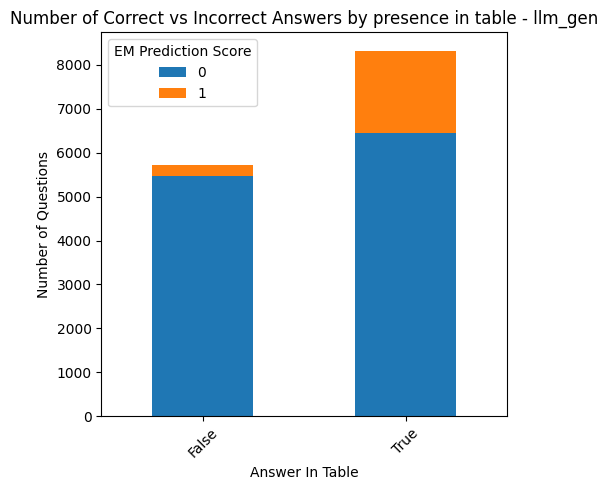

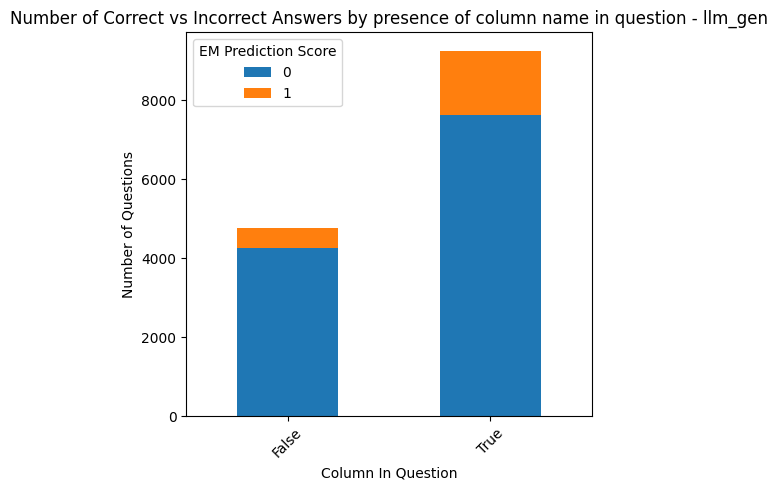

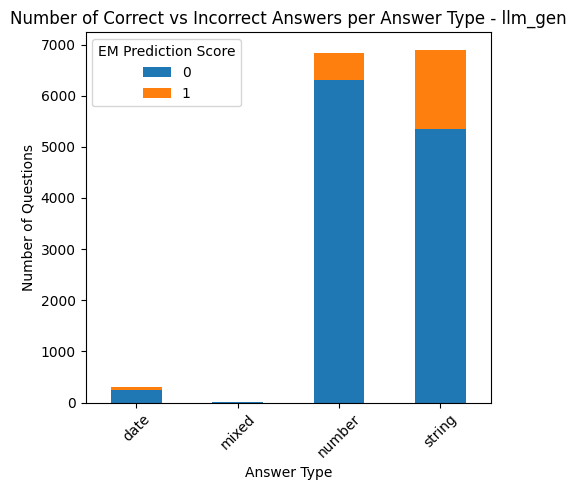

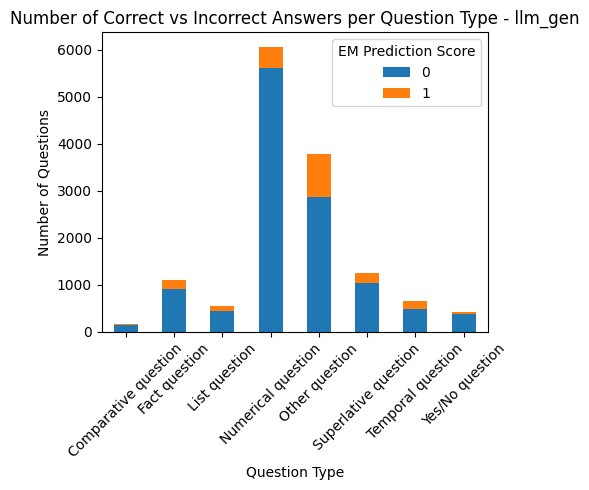

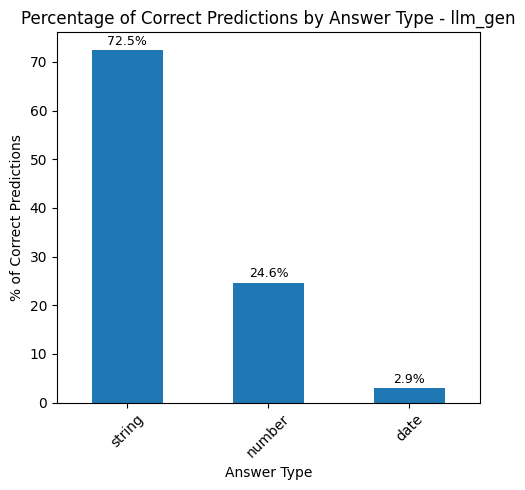

In [27]:
plot_all(1, "train")

# LLM REPRESENTATION 2 with GUIDED Format

In [95]:
# a voir vite fait les tables ou ca cest trompe , on voit bien que les LLMs vont soit halluciner les infos, soit ils vont "resumer" et du coup ils disent des trucs faux.
#on va plutot leur faire suivre un format stricte est clair sujet verbe complement bref, comme ca on tente de minimiser les hallunications.

prompt= "You are an expert data analyst that converts tables into text. For a given table, convert each row in the table into a a single sentence. Do not summarize, instead, generate one sentence per row. You must include all columns names and column values in your sentence. Each sentence must convert a row in the table to a format like : '[column1][verb1][value1], [column2][verb2][value2]...'. The first row represents column names. Include only the paragraph and nothing else. Be neutral and precise. Example: \n Table:\n {table_example} \n Paragraph: {exp_example} \n Now, do the same for this table. \n Table:\n {table} \n Paragraph:  "
table_example="| Party      | Active Voters | Inactive Voters | Total Voters | Percentage |\n| Democratic | 3,683         | 251             | 3,934        | 36.93%     |\n"
exp_example="The Party Democratic has 3,683 active voters , has 251 inactive voters, a total of 3,934 voters, and represents 36.93% of all voters."

prompts= [prompt.format(table=t, table_example= table_example, exp_example=exp_example) for t in table_df["lin_rep"] ]


In [113]:
table_df["lin_rep"][11]

'| Year | Winner       | Jockey             | Trainer                | Owner            | Breeder          |\n| 1919 | Sir Barton   | Johnny Loftus      | H. Guy Bedwell         | J. K. L. Ross    |                  |\n| 1930 | Gallant Fox  | Earl Sande         | Jim Fitzsimmons        | Belair Stud      | Belair Stud      |\n| 1935 | Omaha        | Willie Saunders    | Jim Fitzsimmons        | Belair Stud      | Belair Stud      |\n| 1937 | War Admiral  | Charley Kurtsinger | George H. Conway       | Samuel D. Riddle | Samuel D. Riddle |\n| 1941 | Whirlaway    | Eddie Arcaro       | Ben A. Jones           | Calumet Farm     | Calumet Farm     |\n| 1943 | Count Fleet  | Johnny Longden     | Don Cameron            | Fannie Hertz     | Fannie Hertz     |\n| 1946 | Assault      | Warren Mehrtens    | Max Hirsch             | King Ranch       | King Ranch       |\n| 1948 | Citation     | Eddie Arcaro       | Horace A. Jones        | Calumet Farm     | Calumet Farm     |\n| 1973 | Secretari

In [114]:
res= generator(prompts[11])
res[0]['generated_text'].split("Paragraph:")[-1].split("\nNote")[0]

Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


'   The Year 1919 has Winner Sir Barton, Jockey Johnny Loftus, Trainer H. Guy Bedwell, Owner J. K. L. Ross, and Breeder. The Year 1930 has Winner Gallant Fox, Jockey Earl Sande, Trainer Jim Fitzsimmons, Owner Belair Stud, and Breeder Belair Stud. The Year 1935 has Winner Omaha, Jockey Willie Saunders, Trainer Jim Fitzsimmons, Owner Belair Stud, and Breeder Belair Stud. The Year 1937 has Winner War Admiral, Jockey Charley Kurtsinger, Trainer George H. Conway, Owner Samuel D. Riddle, and Breeder Samuel D. Riddle. The Year 1941 has Winner Whirlaway, Jockey Eddie Arcaro, Trainer Ben A. Jones, Owner Calumet Farm, and Breeder Calumet Farm. The Year 1943 has Winner Count Fleet, Jockey Johnny Longden, Trainer Don Cameron, Owner Fannie Hertz, and Breeder Fannie Hertz. The Year 1946 has Winner Assault, Jockey Warren Mehrtens, Trainer Max Hirsch, Owner King Ranch, and Breeder King Ranch. The Year 1948 has Winner Citation, Jockey Eddie Arcaro, Trainer Horace A. Jones, Owner Calumet Farm, and Breed

In [97]:
x=table_df[table_df["context"]=="csv/204-csv/590.csv"]["lin_rep"].values[0]
x

'| Year | Division | League              | Regular Season | Playoffs        | Open Cup        | Avg. Attendance |\n| 2001 | 2        | USL A-League        | 4th, Western   | Quarterfinals   | Did not qualify | 7,169           |\n| 2002 | 2        | USL A-League        | 2nd, Pacific   | 1st Round       | Did not qualify | 6,260           |\n| 2003 | 2        | USL A-League        | 3rd, Pacific   | Did not qualify | Did not qualify | 5,871           |\n| 2004 | 2        | USL A-League        | 1st, Western   | Quarterfinals   | 4th Round       | 5,628           |\n| 2005 | 2        | USL First Division  | 5th            | Quarterfinals   | 4th Round       | 6,028           |\n| 2006 | 2        | USL First Division  | 11th           | Did not qualify | 3rd Round       | 5,575           |\n| 2007 | 2        | USL First Division  | 2nd            | Semifinals      | 2nd Round       | 6,851           |\n| 2008 | 2        | USL First Division  | 11th           | Did not qualify | 1st Round 

In [105]:
res= generator(prompt.format(table=x, table_example= table_example, exp_example=exp_example))[0]['generated_text']

Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


In [106]:
res.split("Paragraph:")[-1].split("\nNote")[0]

'   The Year 2001 has Division 2, is part of League USL A-League, finished 4th in the Regular Season, reached Quarterfinals in the Playoffs, did not qualify for the Open Cup, and had an average attendance of 7,169. The Year 2002 has Division 2, is part of League USL A-League, finished 2nd in the Regular Season, reached 1st Round in the Playoffs, did not qualify for the Open Cup, and had an average attendance of 6,260. The Year 2003 has Division 2, is part of League USL A-League, finished 3rd in the Regular Season, did not qualify for the Playoffs, did not qualify for the Open Cup, and had an average attendance of 5,871. The Year 2004 has Division 2, is part of League USL A-League, finished 1st in the Regular Season, reached Quarterfinals in the Playoffs, reached 4th Round in the Open Cup, and had an average attendance of 5,628. The Year 2005 has Division 2, is part of League USL First Division, finished 5th, reached Quarterfinals in the Playoffs, reached 4th Round in the Open Cup, and 

In [110]:
print("Question: ------------ ", train_data["utterance"][0])
print("Table RAW---------------------\n",get_rep_from_table(train_data["context"][0],0))
print("Table Rep---------------------\n",res.split("Paragraph:")[-1].split("\nNote")[0])
print("MODEL ANSWER--------------------\n",qa_model(question= train_data["utterance"][0], context=res.split("Paragraph:")[-1].split("\nNote")[0]))
print("Target Answer:-------------------- ", train_data["targetValue"][0])

#bon il se trompe tjrs la, mais au moisn il est moins confiant sur la mauvaise reponse

Question: ------------  what was the last year where this team was a part of the usl a-league?
Table---------------------
    The Year 2001 has Division 2, is part of League USL A-League, finished 4th in the Regular Season, reached Quarterfinals in the Playoffs, did not qualify for the Open Cup, and had an average attendance of 7,169. The Year 2002 has Division 2, is part of League USL A-League, finished 2nd in the Regular Season, reached 1st Round in the Playoffs, did not qualify for the Open Cup, and had an average attendance of 6,260. The Year 2003 has Division 2, is part of League USL A-League, finished 3rd in the Regular Season, did not qualify for the Playoffs, did not qualify for the Open Cup, and had an average attendance of 5,871. The Year 2004 has Division 2, is part of League USL A-League, finished 1st in the Regular Season, reached Quarterfinals in the Playoffs, reached 4th Round in the Open Cup, and had an average attendance of 5,628. The Year 2005 has Division 2, is part 

## evaluation of llm rep2 (GUIDED Format)

In [28]:
results= evaluate_rep(2, "train") #run pour une eval rapide et aggregee
results

{'exact_match': 13.131457071606697, 'f1': 17.514116095822157}

In [29]:
get_nb_gen_fails(2, "train") 
print("--------")
get_nb_qa_fails(2, "train")

Number of times LLm failed to generate= 0 for rep 2 in train 
Percentage of times LLm failed to generate= 0.0 for rep 2 in train 
--------
Number of times QA failed to answer= 148 for rep 2 in train 
Percentage of times QA failed to answer= 1.0545065906661917 for rep 2 in train 


,id,utterance,context,targetValue,tokens,lemmaTokens,posTags,nerTags,nerValues,targetCanon,targetCanonType,utterance_lng,topic,columnInQuestion,valueInQuestion,question_type,answerInTable
68,nt-69,when was the last time kansas state lost with ...,csv/203-csv/703.csv,1964,when|was|the|last|time|kansas|state|lost|with|...,when|be|the|last|time|kansas|state|lose|with|0...,WRB|VBD-AUX|DT|JJ|NN|NNP|NNP|VBD|IN|CD|NNS|IN|...,O|O|O|O|O|ORGANIZATION|ORGANIZATION|O|O|NUMBER...,|||||||||0.0||||,1964.0,number,en,0,False,True,Temporal question,True
74,nt-75,how many places list no zip code in either the...,csv/204-csv/356.csv,18,how|many|places|list|no|zip|code|in|either|the...,how|many|place|list|no|zip|code|in|either|the|...,WRB|JJ|NNS|NN|DT|NN|NN|IN|CC|DT|JJR|CC|JJ|NN|NN|.,O|O|O|O|O|O|O|O|O|O|O|O|O|O|O|O,|||||||||||||||,18.0,number,en,3,True,False,Numerical question,False
191,nt-193,"in 2007, what is the largest number of consecu...",csv/204-csv/294.csv,2,"in|2007|,|what|is|the|largest|number|of|consec...","in|2007|,|what|be|the|largest|number|of|consec...","IN|CD|,|WP|VBD-AUX|DT|JJS|NN|IN|JJ|NNS|VBN|IN|...",O|DATE|O|O|O|O|O|O|O|O|O|O|O|O|LOCATION|O|O|O,|2007||||||||||||||||,2.0,number,en,4,False,True,Numerical question,False
313,nt-315,are there at least 2 nationalities on the chart?,csv/204-csv/482.csv,yes,are|there|at|least|2|nationalities|on|the|chart|?,be|there|at|least|2|nationality|on|the|chart|?,VBD-AUX|EX|IN|JJS|CD|NNS|IN|DT|NN|.,O|O|O|O|NUMBER|O|O|O|O|O,||||>=2.0|||||,yes,string,en,4,False,True,Yes/No question,False
440,nt-442,"in the 197172 national hurling league, how man...",csv/204-csv/525.csv,6,"in|the|197172|national|hurling|league|,|how|ma...","in|the|197172|national|hurl|league|,|how|many|...","IN|DT|CD|JJ|VBG|NN|,|WRB|JJ|NNS|IN|NN|NN|VBD-A...",O|O|NUMBER|MISC|MISC|MISC|O|O|O|O|O|O|O|O|O|O|...,||197172.0||||||||||||||||15.0|||,6.0,number,en,4,True,True,Numerical question,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13806,nt-13922,which country earned the most gold medals?,csv/203-csv/113.csv,Soviet Union (URS),which|country|earned|the|most|gold|medals|?,which|country|earn|the|most|gold|medal|?,WDT|NN|VBD|DT|RBS|JJ|NNS|.,O|O|O|O|O|O|O|O,|||||||,Soviet Union (URS),string,en,0,True,False,Numerical question,True
13808,nt-13924,how many times did kansas state not score at a...,csv/203-csv/703.csv,23,how|many|times|did|kansas|state|not|score|at|a...,how|many|time|do|kansas|state|not|score|at|all...,WRB|JJ|NNS|VBD-AUX|NNP|NNP|RB|NN|IN|DT|IN|NNP|...,O|O|O|O|LOCATION|O|O|NUMBER|O|O|O|ORGANIZATION...,|||||||20.0||||||1902/1968|,23.0,number,en,0,False,True,Numerical question,False
13905,nt-14022,which country is last on the table?,csv/203-csv/653.csv,Tunisia,which|country|is|last|on|the|table|?,which|country|be|last|on|the|table|?,WDT|NN|VBD-AUX|JJ|IN|DT|NN|.,O|O|O|O|O|O|O|O,|||||||,Tunisia,string,en,3,False,False,Numerical question,True
13946,nt-14063,how many sites are there?,csv/204-csv/294.csv,6,how|many|sites|are|there|?,how|many|site|be|there|?,WRB|JJ|NNS|VBD-AUX|EX|.,O|O|O|O|O|O,|||||,6.0,number,en,2,False,False,Numerical question,False


In [ ]:
#vraiment bcp de Q&A qui merdent , ya moyen que ca soit une errur de code pcq je vois pas de raison 
#pk il galere autant a trouver des reponses dans les 2 versions a paragraphes alors que la version lin ca marchait


In [174]:
# results=run_QA(2, qa_model)

The Q&A model failed to generate an answer for: 149 instances. Thye were replaced by 'QA Generation Error'
results saved to ./WikiTableQuestions-1.0.2-compact/WikiTableQuestions/qa_res_2.csv


In [30]:
#example
print("Question: ------------ ", train_data["utterance"][0])
print("Table RAW---------------------\n",get_rep_from_table(train_data["context"][0],0, table_df_train))
print("Table Rep---------------------\n",get_rep_from_table(train_data["context"][0],2, table_df_train))
print("MODEL ANSWER--------------------\n",qa_model(question= train_data["utterance"][0], context=get_rep_from_table(train_data["context"][0],2, table_df_train)))
print("Target Answer:-------------------- ", train_data["targetValue"][0])


#ya une belle amelioration mais il se trompe tjrs sur cet example

Question: ------------  what was the last year where this team was a part of the usl a-league?
Table RAW---------------------
 | Year | Division | League              | Regular Season | Playoffs        | Open Cup        | Avg. Attendance |
| 2001 | 2        | USL A-League        | 4th, Western   | Quarterfinals   | Did not qualify | 7,169           |
| 2002 | 2        | USL A-League        | 2nd, Pacific   | 1st Round       | Did not qualify | 6,260           |
| 2003 | 2        | USL A-League        | 3rd, Pacific   | Did not qualify | Did not qualify | 5,871           |
| 2004 | 2        | USL A-League        | 1st, Western   | Quarterfinals   | 4th Round       | 5,628           |
| 2005 | 2        | USL First Division  | 5th            | Quarterfinals   | 4th Round       | 6,028           |
| 2006 | 2        | USL First Division  | 11th           | Did not qualify | 3rd Round       | 5,575           |
| 2007 | 2        | USL First Division  | 2nd            | Semifinals      | 2nd R

In [ ]:
#il ets moins confiant de la muavaise reponse avec la rep 2 (c'est interessant)

## Analysis of results  llm rep2 (GUIDED Format)

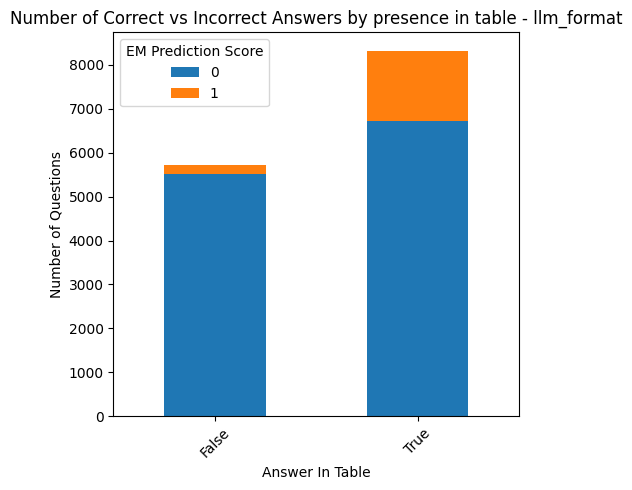

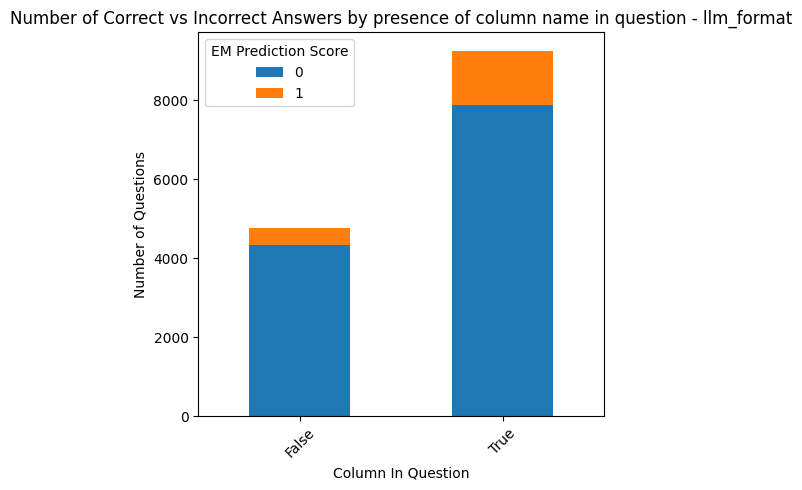

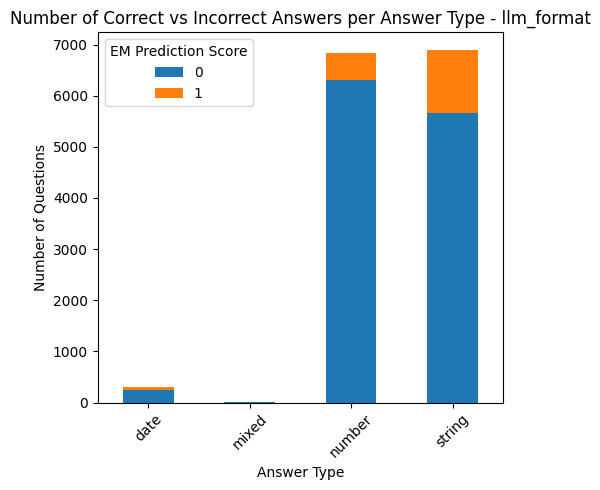

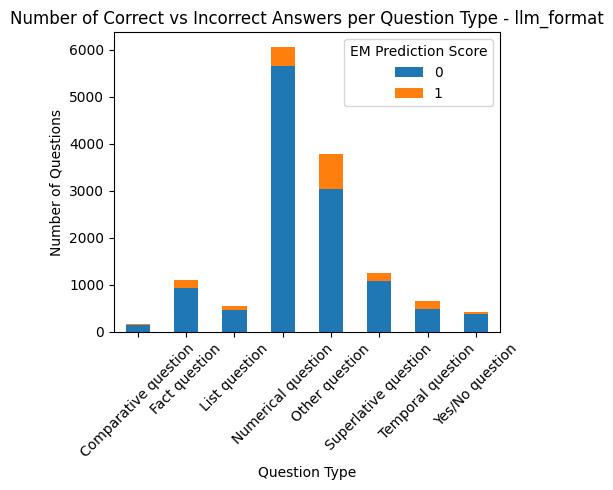

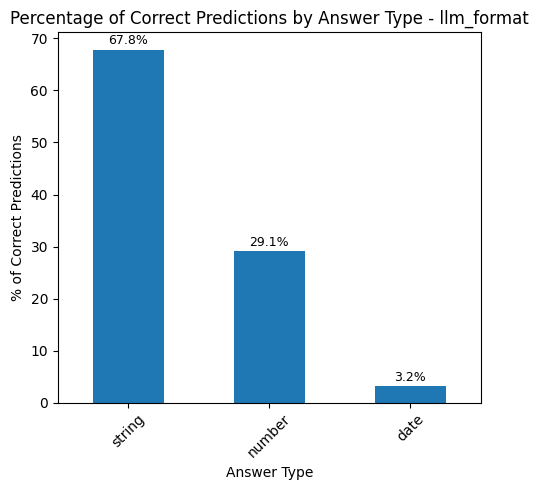

In [31]:
plot_all(2, "train")

In [ ]:
#faut voir comment mieux faire les graphes pcq la on voit aucune differences entre les 3 rep alors que yen a . a refaire

# OVERALL RESULTS
LLM representation >> Format guided >> basic linearization

basic linearization representation : {'exact_match': 10.259333143345682, 'f1': 12.595184846522535}

LMM paragraph row by row representation: {'exact_match': 15.746348414677591, 'f1': 19.180229353206112}

LLM paragraph wiht guided format :{'exact_match': 13.131457071606697, 'f1': 17.514116095822157}

Voir latex pour plus de details


In [ ]:
import matplotlib.pyplot as plt

def plot_predict_by_answertype2(df, column_pred, title):
    
    fig, ax = plt.subplots(figsize=(5,5))
    correct_pred = df[df[column_pred] == 1]
    counts = correct_pred['targetCanonType'].value_counts(normalize=True) * 100
    
    counts.plot(kind='bar', ax=ax)
    ax.set_title(f'Percentage of Correct Predictions by Answer Type - {title}')
    ax.set_xlabel('Answer Type')
    ax.set_ylabel('% of Correct Predictions')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
    plt.tight_layout()

    for i, v in enumerate(counts):
        ax.text(i, v + 0.5, f"{v:.1f}%", ha='center', va='bottom', fontsize=9)

    plt.show()


def plot_predict_by_questionType(df, column_pred, title):
    fig, ax = plt.subplots(figsize=(5,5))
    counts = df.groupby(['question_type', column_pred]).size().unstack(fill_value=0)
    counts.plot(kind='bar', stacked=True, ax=ax)

    ax.set_title(f'Number of Correct vs Incorrect Answers per Question Type - {title}')
    ax.set_xlabel('Question Type')
    ax.set_ylabel('Number of Questions')
    ax.legend(title='EM Prediction Score', labels=['0', '1'])
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
    plt.tight_layout()
    plt.show()


def plot_predict_by_answertype(df, column_pred, title):
    fig, ax = plt.subplots(figsize=(5,5))
    counts = df.groupby(['targetCanonType', column_pred]).size().unstack(fill_value=0)
    counts.plot(kind='bar', stacked=True, ax=ax)

    ax.set_title(f'Number of Correct vs Incorrect Answers per Answer Type - {title}')
    ax.set_xlabel('Answer Type')
    ax.set_ylabel('Number of Questions')
    ax.legend(title='EM Prediction Score', labels=['0', '1'])
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
    plt.tight_layout()
    plt.show()


def plot_predict_by_answerinTable(df, column_pred, title):
    fig, ax = plt.subplots(figsize=(5,5))
    counts = df.groupby(['answerInTable', column_pred]).size().unstack(fill_value=0)
    counts.plot(kind='bar', stacked=True, ax=ax)

    ax.set_title(f'Number of Correct vs Incorrect Answers by presence in table - {title}')
    ax.set_xlabel('Answer In Table')
    ax.set_ylabel('Number of Questions')
    ax.legend(title='EM Prediction Score', labels=['0', '1'])
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
    plt.tight_layout()
    plt.show()

def plot_predict_by_columnInQuestion(df, column_pred, title):
    fig, ax = plt.subplots(figsize=(5,5))
    counts = df.groupby(['columnInQuestion', column_pred]).size().unstack(fill_value=0)
    counts.plot(kind='bar', stacked=True, ax=ax)

    ax.set_title(f'Number of Correct vs Incorrect Answers by presence of column name in question - {title}')
    ax.set_xlabel('Column In Question')
    ax.set_ylabel('Number of Questions')
    ax.legend(title='EM Prediction Score', labels=['0', '1'])
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
    plt.tight_layout()
    plt.show()

def plot_all(rep, suffixe ):
    res_data= pd.read_csv(f"./WikiTableQuestions-1.0.2-compact/WikiTableQuestions/qa_res_{suffixe}_{rep}.csv")
    if suffixe=="train":
        data= pd.read_csv("WikiTableQuestions-1.0.2-compact/WikiTableQuestions/tagged/data/EN_training_cleaned.tagged")
    else:
        data= pd.read_csv("WikiTableQuestions-1.0.2-compact/WikiTableQuestions/tagged/data/EN_pristine-unseen-tables_cleaned.tagged")

    data_and_res= pd.merge(data, res_data, on="id", how="inner") #merge both files to access predictions and data features

    
    plot_predict_by_answerinTable(data_and_res, f"EM_score_pred_{rep}", map_rep[rep])
    plot_predict_by_columnInQuestion(data_and_res, f"EM_score_pred_{rep}", map_rep[rep])
    plot_predict_by_answertype(data_and_res,  f"EM_score_pred_{rep}", map_rep[rep])
    plot_predict_by_questionType(data_and_res, f"EM_score_pred_{rep}", map_rep[rep])
    plot_predict_by_answertype2(data_and_res,  f"EM_score_pred_{rep}", map_rep[rep])


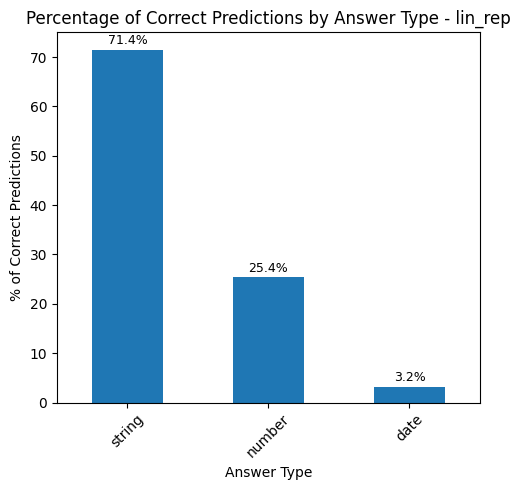

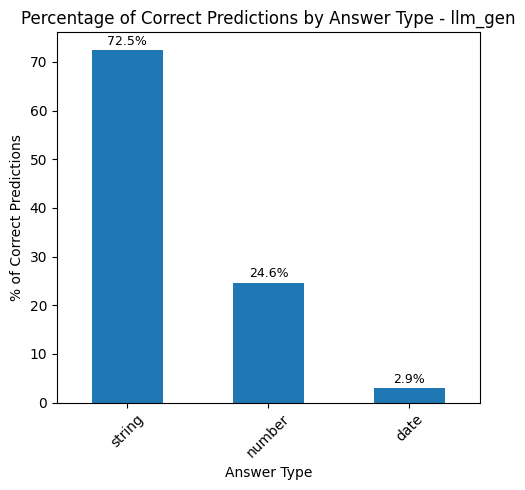

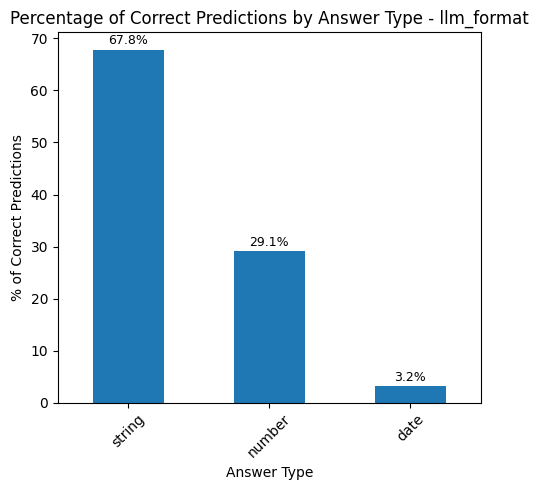

In [13]:
plot_all_new()

In [6]:
q_a_res_0 = pd.read_csv("WikiTableQuestions-1.0.2-compact/WikiTableQuestions/qa_res_train_0.csv")
q_a_res_1 = pd.read_csv("WikiTableQuestions-1.0.2-compact/WikiTableQuestions/qa_res_train_1.csv")
q_a_res_2 = pd.read_csv("WikiTableQuestions-1.0.2-compact/WikiTableQuestions/qa_res_train_2.csv")

In [7]:
q_a_res_0.head()

,id,pred_0,EM_score_pred_0
0,nt-0,2001,0
1,nt-1,Bangkok,0
2,nt-2,Greystones,0
3,nt-3,"14,749",0
4,nt-4,Oldfield,0


In [8]:
q_a_res = pd.merge(q_a_res_0, q_a_res_1, on = ['id']).drop_duplicates(ignore_index = True)
q_a_res = pd.merge(q_a_res,q_a_res_2, on = ["id"]).drop_duplicates(ignore_index=True)

In [9]:
q_a_res
data= pd.read_csv("WikiTableQuestions-1.0.2-compact/WikiTableQuestions/tagged/data/EN_training_cleaned.tagged")

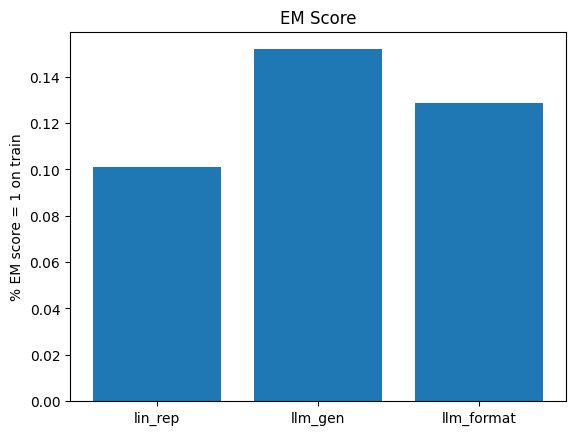

In [10]:
em_count = q_a_res[['EM_score_pred_0','EM_score_pred_1','EM_score_pred_2']].sum(axis =0)

fig,ax = plt.subplots()
ax.bar(["lin_rep","llm_gen","llm_format"],em_count/len(q_a_res))
ax.set_title("EM Score")
ax.set_ylabel('% EM score = 1 on train')
plt.show()

In [11]:
q_a_res =q_a_res.merge(data[['id','columnInQuestion', 'valueInQuestion',
       'question_type', 'answerInTable']], on = ["id"])

In [12]:
q_a_res.columns

Index(['id', 'pred_0', 'EM_score_pred_0', 'pred_1', 'EM_score_pred_1',
       'pred_2', 'EM_score_pred_2', 'columnInQuestion', 'valueInQuestion',
       'question_type', 'answerInTable'],
      dtype='object')

In [15]:
q_a_res.head()

,id,pred_0,EM_score_pred_0,pred_1,EM_score_pred_1,pred_2,EM_score_pred_2,columnInQuestion,valueInQuestion,question_type,answerInTable
0,nt-0,2001,0,2001,0,2001,0,True,True,Other question,True
1,nt-1,Bangkok,0,Bangkok,0,Venue Grosseto,0,False,True,Other question,True
2,nt-2,Greystones,0,Crettyard,0,The Team Ballymore Eustace,0,True,True,Other question,True
3,nt-3,"14,749",0,"14,749",0,"2,282",0,True,True,Numerical question,False
4,nt-4,Oldfield,0,Derby County,1,Charlton Athletic,0,True,False,Other question,True


In [23]:

count_columnInQuestion = q_a_res.groupby(["columnInQuestion"])[["EM_score_pred_0","EM_score_pred_1","EM_score_pred_2"]].sum()

In [ ]:
plt.figure()
fig, ax = plt.subplots()
plt.bar(["True",""])

,EM_score_pred_0,EM_score_pred_1,EM_score_pred_2
columnInQuestion,,,
False,360,507,433
True,1058,1625,1374
